In [2]:
# BEFORE importing cupy 
import os

GPU_IDs = [1] # IDs of GPUs that are available (cross-check with gpustat in a terminal)
IDs_txt = ",".join(map(str, GPU_IDs)) # "ID[0],ID[1],ID[2],..."
os.environ["CUDA_VISIBLE_DEVICES"] = IDs_txt # Only these GPUS will be seen by the program after this line 

import numpy 
import cupy as np
import sys,os
from pathlib import Path
import time as time_wall
# Import subroutines
from subroutines import *

# Read input parameters
from parameter import *

In [3]:
import matplotlib.pyplot as plt
#  For loading field
# import field_calc

In [4]:
######################
### INITIALIZATION ###
######################
# # Set up log
# log = open('./log.txt','a')
# sys.stdout = log

# # Create a 'RUNNING.txt' file
# with open('./RUNNING.txt', 'w') as creating_new_txt_file:
#     pass
# print("Empty RUNNING File Created Successfully",flush=True)

# # If the seed is fed through an argument, it supersedes the one provided by parameter.py
# num_args = len(sys.argv)
# if num_args>1:
#     seed = int(sys.argv[1])
#     print('Using new seed = %s' % seed, flush = True)

# Initialize random number generator (using numpy because it's faster)
rng = numpy.random.default_rng(seed)

#########################
### PRECOMPUTE ARRAYS ###
#########################
# Builds the wave number and the square wave number matrixes
# In spectral space, index 0 is the kx axis, index 1 is the ky axis
# In real space, index 0 is the x axis, index 1 is the y axis
ka = np.asarray(np.fft.fftfreq(n,d=(1/n)),dtype=Tf) # kx
ka_half = np.asarray(np.fft.rfftfreq(n,d=(1/n)),dtype=Tf) # ky
KX,KY = np.meshgrid(ka,ka_half,indexing='ij')
ka2 = KX**2+KY**2
# Imaginary matrix
I = 1j*np.ones((n,n_half),dtype=Tc)
# For shell integrating
inds_polar = []
for ii in range(n_half):
    kk = ii+1
    inds_polar.append(np.where(np.round(np.sqrt(ka2)).astype(Ti)==kk))

# If recording triad statistics, load relevant information
if triad_phase_hist:
    # Load triads for histogram
    triads = np.loadtxt(idir+'/triads.txt',dtype=Ti)
    Ntriads = triads.shape[0]
    print("Gathering histogram statistics for %s triads." % Ntriads, flush = True)
    # Define histogram
    thetauuu = np.zeros((Nbins,Ntriads),dtype=Ti)

    # Check to see if triad_pair_list.txt file exists:
    my_file = Path(idir+'/triad_pair_list.txt')
    triad_pairs = my_file.is_file()
    if triad_pairs:
        # Loads info on triad pairs for joint histogram
        triad_pair_list = np.loadtxt(idir+'/triad_pair_list.txt',dtype=Ti)
        Npairs= triad_pair_list.shape[0]
        print("Gathering histogram statistics for %s triads." % Ntriads, flush = True)
        # Define joint histogram
        thetauuu_joint = np.zeros((Nbins,Nbins,Npairs),dtype=Ti)
    else:
        # Create empty thetauuu_joint because thetauuu_calc will output that anyways
        triad_pair_list = np.nan
        Npairs = np.nan
        thetauuu_joint = np.zeros((1,1,1),dtype=Ti)
    
    # Define scriptK and other averaged quantities
    scriptK = np.zeros((2,Ntriads),dtype=Tf)
    rhok = np.zeros((2,Ntriads),dtype=Tf)
    rhop = np.zeros((2,Ntriads),dtype=Tf)
    rhoq = np.zeros((2,Ntriads),dtype=Tf)
    Rkpq = np.zeros((2,Ntriads),dtype=Tf)
    Tkpq = np.zeros((2,Ntriads),dtype=Tf)
    # Set count to zero for averages
    i_count = 0

    # # Now process time-series triads
    # triads_ts = np.loadtxt(idir+'/triads_ts.txt',dtype=Ti)
    # Ntriads_ts = triads_ts.shape[0]
    # print("Gathering temporal statistics for %s triads." % Ntriads_ts, flush = True)
    
    # Compute index arrays, indKX,indKY,indPX, etc. X arrays have shape (Ntriads,n), Y arrays have shape (n,Ntriads)
    # To be used in thetauuu_calc
    indKX = np.zeros((Ntriads,n),dtype=Tf)
    indKY = np.zeros((n_half,Ntriads),dtype=Tf)
    indPX = np.zeros((Ntriads,n),dtype=Tf)
    indPY = np.zeros((n_half,Ntriads),dtype=Tf)
    indQX = np.zeros((Ntriads,n),dtype=Tf)
    indQY = np.zeros((n_half,Ntriads),dtype=Tf)
    kmag = np.zeros((Ntriads),dtype=Tf)
    pmag = np.zeros((Ntriads),dtype=Tf)
    qmag = np.zeros((Ntriads),dtype=Tf)
    for Ntr,triad in enumerate(triads):
        kx,ky,px,py = triad 
        qx = -kx-px
        qy = -ky-py
        # Magnitudes
        kmag[Ntr] = np.sqrt(kx**2+ky**2)
        pmag[Ntr] = np.sqrt(px**2+py**2)
        qmag[Ntr] = np.sqrt(qx**2+qy**2)
    
        # k
        if (ky>=0): # phi(kx,ky)
            sgn=1
        else: # -phi(-kx,-ky)
            ky=-ky
            kx=-kx
            sgn=-1
        indKX[Ntr,ka==kx] = sgn
        indKY[ka_half==ky,Ntr] = 1
    
        # p
        if (py>=0): # phi(px,py)
            sgn=1
        else: # -phi(-px,-py)
            py=-py
            px=-px
            sgn=-1
        indPX[Ntr,ka==px] = sgn
        indPY[ka_half==py,Ntr] = 1
        
        # q
        if (qy>=0): # phi(qx,qy)
            sgn=1
        else: # -phi(-qx,-qy)
            qy=-qy
            qx=-qx
            sgn=-1
        indQX[Ntr,ka==qx] = sgn
        indQY[ka_half==qy,Ntr] = 1
        
    # # To be used in corr_check (time-series of theta statistics)
    # indKX_ts = np.zeros((Ntriads_ts,n),dtype=Tf)
    # indKY_ts = np.zeros((n_half,Ntriads_ts),dtype=Tf)
    # indPX_ts = np.zeros((Ntriads_ts,n),dtype=Tf)
    # indPY_ts = np.zeros((n_half,Ntriads_ts),dtype=Tf)
    # indQX_ts = np.zeros((Ntriads_ts,n),dtype=Tf)
    # indQY_ts = np.zeros((n_half,Ntriads_ts),dtype=Tf)
    # kmag_ts = np.zeros((Ntriads_ts),dtype=Tf)
    # pmag_ts = np.zeros((Ntriads_ts),dtype=Tf)
    # qmag_ts = np.zeros((Ntriads_ts),dtype=Tf)
    # qxp_ts = np.zeros((Ntriads_ts),dtype=Tf)
    # for Ntr,triad in enumerate(triads_ts):
    #     kx,ky,px,py = triad 
    #     qx = -kx-px
    #     qy = -ky-py
        
    #     # qxp
    #     qxp_ts[Ntr] = qx*py-px*qy
        
    #     # Magnitudes
    #     kmag_ts[Ntr] = np.sqrt(kx**2+ky**2)
    #     pmag_ts[Ntr] = np.sqrt(px**2+py**2)
    #     qmag_ts[Ntr] = np.sqrt(qx**2+qy**2)
    
    #     # k
    #     if (ky>=0): # phi(kx,ky)
    #         sgn=1
    #     else: # -phi(-kx,-ky)
    #         ky=-ky
    #         kx=-kx
    #         sgn=-1
    #     indKX_ts[Ntr,ka==kx] = sgn
    #     indKY_ts[ka_half==ky,Ntr] = 1
    
    #     # p
    #     if (py>=0): # phi(px,py)
    #         sgn=1
    #     else: # -phi(-px,-py)
    #         py=-py
    #         px=-px
    #         sgn=-1
    #     indPX_ts[Ntr,ka==px] = sgn
    #     indPY_ts[ka_half==py,Ntr] = 1
        
    #     # q
    #     if (qy>=0): # phi(qx,qy)
    #         sgn=1
    #     else: # -phi(-qx,-qy)
    #         qy=-qy
    #         qx=-qx
    #         sgn=-1
    #     indQX_ts[Ntr,ka==qx] = sgn
    #     indQY_ts[ka_half==qy,Ntr] = 1

##########################
### INITIAL CONDITIONS ###
##########################
# Read status.py
stat,t,time = np.loadtxt('./status.py') # stat is the output number
stat = int(stat)
t = int(t)
ini = t

if stat==0:
    dump = 0 # For use in spectra and transfers
    t = 1 # Initial time-step
    timet = tstep
    timec = cstep
    times = sstep
    timeth = thstep
    timethts = thtsstep

    # Stream function IC (random phase up to kup)
    ps = np.zeros((Nens,n,n_half),dtype=Tc)
    phase = rng.uniform(low=-np.pi,high=np.pi,size=ps.shape)
    phase = np.asarray(phase,dtype=Tf)
    cond = (ka2<=kup**2)&(ka2>=tiny)
    ps = (np.sqrt(ka2[None,:,:])/kup)**((-alpha-3.0)/2.0) * (np.cos(phase) + 1j*np.sin(phase)) * cond[None,:,:]
    # Ensure 'realness' in the ky = 0 axis:
    ps[:,n_half:,0] = np.flip(np.conj(ps[:,1:n_half-1,0]),axis=1)
    ps[:,0,0] = ps[:,n_half-1,0] = 0.0

    # Renormalize
    E = energy(ps,1,ka2)
    ps *= np.sqrt(2.0*u0/E[:,None,None])
else:
    dump = np.int64(np.float64(t)/np.float64(sstep))
    times = t%sstep
    timet = t%tstep
    timec = t%cstep
    timeth = t%thstep
    timethts = t%thtsstep

    # Load the saved output file
    R1 = np.load(idir+'/ps.'+f'{int(stat):03}'+'.npy')
    R1 = np.asarray(R1,dtype=Tf)

    # FFT to get ps
    ps = np.fft.rfftn(R1,axes=(1,2))
    
    Nens_t,_,_ = ps.shape
    if Nens_t<Nens:
        print('Nens in parameter.py does NOT match Nens from the input file. Changing Nens to match the input file. Nens = %i --> Nens = %i' % (Nens,Nens_t), flush=True)
        Nens = Nens_t
    elif Nens_t>Nens:
        print('Nens in parameter.py does NOT match Nens from the input file. Changing the shape of ps to match Nens. shape[0] = %i --> %i' % (ps.shape[0],Nens), flush=True)
        ps = ps[:Nens,:,:]

    # If traid_phase_hist, then load the histogram array
    if triad_phase_hist:
        # Check to see if thetauuu file exists:
        my_file = Path(odir+'/thetauuu.npy')
        if my_file.is_file():
            # Load
            thetauuu[:] = np.load(my_file)[:]

        if triad_pairs:
            # Check to see if thetauuu_joint file exists:
            my_file = Path(odir+'/thetauuu_joint.npy')
            if my_file.is_file():
                # Load
                thetauuu_joint[:] = np.load(my_file)[:]

        # Check to see if scriptK file exists:
        my_file = Path(odir+'/scriptK.npy')
        if my_file.is_file():
            # Load
            scriptK[:] = np.load(my_file)[:]
        # Check to see if rhok file exists:
        my_file = Path(odir+'/rhok.npy')
        if my_file.is_file():
            # Load
            rhok[:] = np.load(my_file)[:]
        # Check to see if rhop file exists:
        my_file = Path(odir+'/rhop.npy')
        if my_file.is_file():
            # Load
            rhop[:] = np.load(my_file)[:]
        # Check to see if rhoq file exists:
        my_file = Path(odir+'/rhoq.npy')
        if my_file.is_file():
            # Load
            rhoq[:] = np.load(my_file)[:]
        # Check to see if Rkpq file exists:
        my_file = Path(odir+'/Rkpq.npy')
        if my_file.is_file():
            # Load
            Rkpq[:] = np.load(my_file)[:]
        # Check to see if Tkpq file exists:
        my_file = Path(odir+'/Tkpq.npy')
        if my_file.is_file():
            # Load
            Tkpq[:] = np.load(my_file)[:]

        # Also load the count file, if it exists:
        my_file = Path(odir+'/i_count.npy')
        if my_file.is_file():
            # Load
            i_count = int(np.load(my_file))
            print('Continuing averages, i_count = %i' % i_count, flush=True)


print('Starting from time-step %s and time %.3f.' % (t,time), flush=True)

###############
### FORCING ###
###############
dt = CFL_condition(ps,KX,KY,I)
if iflow==1:
    # Stream function forcing (kdn to kup)
    fp = np.zeros((Nens,n,n_half),dtype=Tc)
    cond = (ka2<=kup**2)&(ka2>=kdn**2)
    phase = rng.uniform(low=-np.pi,high=np.pi,size=fp.shape)
    phase = np.asarray(phase,dtype=Tf)
    fp = (np.cos(phase) + 1j*np.sin(phase)) * cond[None,:,:]
    # Ensure 'realness' in the ky = 0 axis:
    fp[:,n_half:,0] = np.flip(np.conj(fp[:,1:n_half-1,0]),axis=1)
    fp[:,0,0] = fp[:,n_half-1,0] = 0.0
    
    # Renormalize
    E = energy(fp,1,ka2)
    fp *= fp0/np.sqrt(E[:,None,None])
elif iflow==2:
    fp = const_inj(ps,ka2,rng)
elif iflow==3:
    cond_rand_force = ka2[None,:,:]*np.ones((Nens,n,n_half),dtype=Tf)
    cond_rand_force = ((cond_rand_force<kup**2)&(cond_rand_force>kdn**2))
    # Reshape each ensemble as 1D array
    cond_rand_force = cond_rand_force.reshape(Nens, n*n_half)  # (Nens, P)
    # Count the number of 'True' values per ensemble
    counts = cond_rand_force.sum(axis=1)
    # Cumulative sum increments only at True entries
    cond_rand_force = np.cumsum(cond_rand_force, axis=1)
    fp = rand_force(dt,ka2,ka,ka_half,rng,cond_rand_force,counts)
else:
    sys.exit('ERROR. The variable iflow must be either 1, 2, or 3. Stopping simulation.')

Gathering histogram statistics for 8289 triads.
Starting from time-step 1 and time 0.000.


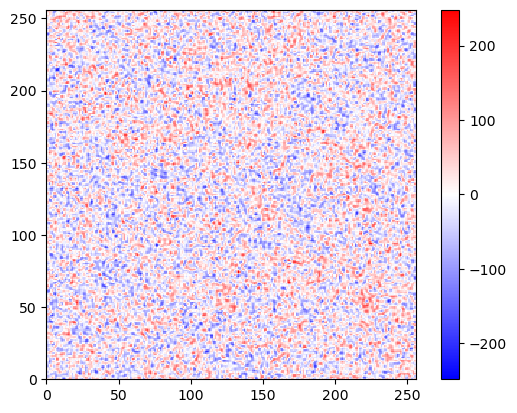

In [5]:
ww = -laplak2(ps[0,:,:],ka2)
im = np.fft.irfftn(ww)
cbar = np.max(np.abs(im))
plt.pcolor(im.get(),vmin=-cbar,vmax=cbar,cmap='bwr')
plt.colorbar()
plt.gca().set_aspect(1)
plt.show()

# Single-variable histogram

In [6]:
Ntriads = indKX.shape[0]
    
tmp = 1/n**2

# Update counter:
i_count += 1

# Build the bin centers
dtheta = 2*np.pi/Nbins
bins_centered = -np.pi + dtheta/2 + dtheta*np.arange(Nbins)

# Isolate individual triad rhos and phis
rhos = np.abs(ps)
rhoks = np.abs(np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indKX, rhos),indKY)) # Need abs to prevent rho<0 due to sgn
rhops = np.abs(np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indPX, rhos),indPY)) # Need abs to prevent rho<0 due to sgn
rhoqs = np.abs(np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indQX, rhos),indQY)) # Need abs to prevent rho<0 due to sgn
phis = np.angle(ps)
phiks = np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indKX, phis),indKY)
phips = np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indPX, phis),indPY)
phiqs = np.einsum('lik,ki->li',np.einsum('ij,ljk->lik', indQX, phis),indQY)

In [7]:
print(thetauuu[:,3])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [8]:
# thetauuu = np.zeros((Nbins,Ntriads),dtype=Ti)

In [9]:
# Set some random rhos to zero for testing
flat_ind = np.asarray(rng.choice(np.arange(Nens*Ntriads).get(),size=500,replace=False),dtype=Ti)
# print(flat_ind[:10])
flat_rhoks = rhoks.flatten()
flat_rhoks[flat_ind]=0.0
rhoks = flat_rhoks.reshape((Nens,Ntriads))

Old method

In [10]:
thetauuu_old = np.copy(thetauuu[:])
## Define thetauuu
thetas = phiks+phips+phiqs
thetas = thetas - 2*np.pi*np.round(thetas/np.pi/2) # From [-pi,pi]
# print(thetas.shape)
# For removing thetas where one or more rhos == 0.
valid_indices_ens, valid_indices_tri = np.where(np.abs(rhoks*rhoqs*rhops)>0)
thetas_valid = thetas[valid_indices_ens,valid_indices_tri] # shape = Nens*Ntriads - N_removed
# print(thetas_valid.shape,Ntriads*Nens-500)
# Shift thetas to the [0, 2pi) range
shifted_thetas = (thetas_valid + np.pi) % (2 * np.pi)
# Find which 'bin' of the theta pdf it should go into and add one to the histogram
# Compute bin indices
bin_indices = np.floor(shifted_thetas / dtheta).astype(Ti) # shape = Nens*Ntriads - N_removed
## Combine bin + triad index into 1D index
# bincounting bin_indices would sum up all of the triads together into one PDF. 
# We want to isolate different triads, but sum up triads that are the same over different ensemble members.
# So if bin_index and valid_indices_tri are the same, we want them to have the same number. However, we want to avoid 
# the possibility of bin_index + valid_indices_tri being equal for different combinations of bin_index and 
# valid_indices_tri. Therefore, we multiply bin_index by Ntriads. Note: values are spanned by 0 bin index + triad 0
# = 0 to index 29 + triad Ntriad = 30*Ntriad = Nbin*Ntriad. 
flat_idx = bin_indices * Ntriads + valid_indices_tri
# Count with bincount (1D)
counts = np.bincount(flat_idx, minlength=Nbins * Ntriads)
# Reshape to (Nbins, Ntriads) and add to thetauuu
thetauuu_old += counts.reshape((Nbins, Ntriads))

New method

In [11]:
thetauuu_new = np.copy(thetauuu[:])
## Define thetauuu
thetas = phiks+phips+phiqs
thetas = thetas - 2*np.pi*np.round(thetas/np.pi/2) # From [-pi,pi]
# For removing thetas where one or more rhos == 0.
valid = np.abs(rhoks*rhoqs*rhops)>0
_,valid_indices_tri = np.where(valid) # shape = Nens*Ntriads - N_removed
# Shift thetas to the [0, 2pi) range
shifted_thetas = (thetas + np.pi) % (2 * np.pi)
# Find which 'bin' of the theta pdf it should go into and add one to the histogram
# Compute bin indices
bin_indices = np.floor(shifted_thetas / dtheta).astype(Ti) # shape = (Nens,Ntriads)

### 1D histograms
## Combine bin + triad index into 1D index
# bincounting bin_indices would sum up all of the triads together into one PDF. 
# We want to isolate different triads, but sum up triads that are the same over different ensemble members.
# So if bin_index and valid_indices_tri are the same, we want them to be added to the same bin. However, we want to avoid 
# the possibility of bin_index + valid_indices_tri being equal for different combinations of bin_index and 
# valid_indices_tri. Therefore, we multiply bin_index by Ntriads. Note: values are spanned by 0 bin index + triad 0 
# = flat_idx 0 to index 29 + triad Ntriad = 30*Ntriad = Nbin*Ntriad. Each bin in each triad has a unique ID.
flat_idx = bin_indices[valid] * Ntriads + valid_indices_tri
# Count with bincount (1D)
counts = np.bincount(flat_idx, minlength=Nbins * Ntriads)
# Reshape to (Nbins, Ntriads) and add to thetauuu
thetauuu_new += counts.reshape((Nbins, Ntriads))

In [12]:
np.all(thetauuu_new==thetauuu_old)

array(True)

# Joint histogram

In [13]:
triad_pair_list = []

k_groups = {}
p_groups = {}
for i, triad in enumerate(triads):
    # --------------------------------------------------
    # Group triads according to their k = (kx, ky)
    # --------------------------------------------------
    k = (int(triad[0]), int(triad[1]))

    if k not in k_groups:
        k_groups[k] = []

    k_groups[k].append(i)

    # --------------------------------------------------
    # Group triads according to their p = (px, py)
    # --------------------------------------------------
    p = (int(triad[2]), int(triad[3]))

    if p not in p_groups:
        p_groups[p] = []

    p_groups[p].append(i)


# --------------------------------------------------
# Create pairs from the k groups
# --------------------------------------------------
for indices in k_groups.values():

    # Every pair within this group shares the same k
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            triad_pair_list.append([indices[i], indices[j]])


# --------------------------------------------------
# Create pairs from the p groups
# --------------------------------------------------
for indices in p_groups.values():

    # Every pair within this group shares the same p
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            triad_pair_list.append([indices[i], indices[j]])

triad_pair_list = np.asarray(triad_pair_list, dtype=Ti)

In [14]:
np.savetxt('./triad_pair_list.bak', triad_pair_list, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

In [16]:
Npairs= triad_pair_list.shape[0]
thetauuu_joint = np.zeros((Nbins,Nbins,Npairs),dtype=Ti)

In [17]:
Npairs = triad_pair_list.shape[0]

# Triad indices for each pair (shape = (Npairs))
triad1 = triad_pair_list[:, 0]
triad2 = triad_pair_list[:, 1]

# Bin index for each pair (shape = (Nens,Npairs))
bin1 = bin_indices[:, triad1]
bin2 = bin_indices[:, triad2]

# A pair is valid only if BOTH triads are valid (shape = (Nens,Npairs))
valid_pairs = valid[:, triad1] & valid[:, triad2]

# Keep only valid pair contributions. (flattens, shape = (Nens*Npairs-Npairs_removed))
bin1 = bin1[valid_pairs]
bin2 = bin2[valid_pairs]

# Flatten valid_pairs
_,valid_pair_inds = np.where(valid_pairs) # shape = Nens*Npairs-Npairs_removed

## Convert (Nbins,Nbins,Ntriads) to one index
flat_idx = (bin1*Nbins+bin2)*Npairs+valid_pair_inds

# Histogram all three dimensions simultaneously
counts = np.bincount(flat_idx,minlength=Nbins * Nbins * Npairs)

# Reshape back to (Nbins, Nbins, Npairs)
thetauuu_joint += counts.reshape(Nbins, Nbins, Npairs)

In [18]:
triads.shape

(8289, 4)

In [19]:
triad_pair_list[:4,:4]

array([[  3,  50],
       [  3,  53],
       [  3, 112],
       [  3, 115]])

In [20]:
triad1[0]

array(3)

In [21]:
triads[triad1[0],:]

array([  0, -18, -18,  -1])

In [22]:
triads[triad2[0],:]

array([  0, -18, -32, -20])

In [25]:
np.sum(thetauuu_joint[:,:,0],axis=0)

array([1, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 5, 4, 0, 0, 0, 0, 2, 1, 2, 1, 1,
       0, 3, 2, 0, 1, 1, 2, 1])

In [26]:
thetauuu_new[:,triad2[0]]

array([1, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 5, 4, 0, 0, 0, 0, 2, 1, 2, 1, 1,
       0, 3, 2, 0, 1, 1, 2, 1])